# 💬 Lecture 7, Regex – Data 100, Fall '26

[Acknowledgments Page](https://ds100.org/acknowledgements/)


## 🤠 Text Wrangling and Regex

Working with text: applying string methods and regular expressions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import zipfile
import polars as pl

## 🥫 Demo 1: Canonicalizing County Names

In [2]:
states = pl.read_csv("data/county_and_state.csv")
populations = pl.read_csv("data/county_and_population.csv")

# display() allows us to view a DataFrame without returning it as an object
display(states)
display(populations)

County,State
str,str
"""De Witt County""","""IL"""
"""Lac qui Parle County""","""MN"""
"""Lewis and Clark County""","""MT"""
"""St John the Baptist Parish""","""LS"""


County,Population
str,i64
"""DeWitt""",16798
"""Lac Qui Parle""",8067
"""Lewis & Clark""",55716
"""St. John the Baptist""",43044


Both of these DataFrames share a "County" column. Unfortunately, formatting differences mean that we can't directly join the two DataFrames using the "County"s.

In [3]:
states.join(populations, left_on="County", right_on="County", how="left")

County,State,Population
str,str,i64
"""De Witt County""","""IL""",null
"""Lac qui Parle County""","""MN""",null
"""Lewis and Clark County""","""MT""",null
"""St John the Baptist Parish""","""LS""",null


### 🐻‍❄️ Using Polars String Functions

To address this, we can **canonicalize** the "County" string data to apply a common formatting.

In [4]:
# Function to transform a series of county names into a standard form
def canonicalize_county(county_series):
    canonicalized_series = (
        county_series
        .str.to_lowercase()  # make lowercase
        .str.replace_all(' ', '', literal=True)  # remove spaces
        .str.replace_all('&', 'and', literal=True)  # replace & with and
        .str.replace_all('.', '', literal=True)    # remove dots
        .str.replace_all('county', '', literal=True)  # remove "county"
        .str.replace_all('parish', '', literal=True)     # remove "parish"
    )
    return canonicalized_series

display(canonicalize_county(states["County"]))
display(canonicalize_county(populations["County"]))

County
str
"""dewitt"""
"""lacquiparle"""
"""lewisandclark"""
"""stjohnthebaptist"""


County
str
"""dewitt"""
"""lacquiparle"""
"""lewisandclark"""
"""stjohnthebaptist"""


In [5]:
states = states.with_columns(
    canonicalize_county(states["County"]).alias("Canonical County")
)

populations = populations.with_columns(
    canonicalize_county(populations["County"]).alias("Canonical County")
)

display(states)
display(populations)

County,State,Canonical County
str,str,str
"""De Witt County""","""IL""","""dewitt"""
"""Lac qui Parle County""","""MN""","""lacquiparle"""
"""Lewis and Clark County""","""MT""","""lewisandclark"""
"""St John the Baptist Parish""","""LS""","""stjohnthebaptist"""


County,Population,Canonical County
str,i64,str
"""DeWitt""",16798,"""dewitt"""
"""Lac Qui Parle""",8067,"""lacquiparle"""
"""Lewis & Clark""",55716,"""lewisandclark"""
"""St. John the Baptist""",43044,"""stjohnthebaptist"""


Now, the join works as expected!

In [6]:
states.join(populations, on="Canonical County", how="left")

County,State,Canonical County,County_right,Population
str,str,str,str,i64
"""De Witt County""","""IL""","""dewitt""","""DeWitt""",16798
"""Lac qui Parle County""","""MN""","""lacquiparle""","""Lac Qui Parle""",8067
"""Lewis and Clark County""","""MT""","""lewisandclark""","""Lewis & Clark""",55716
"""St John the Baptist Parish""","""LS""","""stjohnthebaptist""","""St. John the Baptist""",43044


<br /><br /><br />

**Instructor note: Return to Slides!**

<br /><br /><br />


---

## 🪵 Demo 2: Extracting Data from Log Files

In [7]:
# Sample log file
log_fname = 'data/log.txt'

with open(log_fname, 'r') as f:
    # readlines() returns a list of strings, 
    # with each element representing a line in the file
    log_lines = f.readlines()
    
log_lines

['169.237.46.168 - - [26/Jan/2014:10:47:58 -0800] "GET /stat141/Winter04/ HTTP/1.1" 200 2585 "http://anson.ucdavis.edu/courses/"\n',
 '193.205.203.3 - - [2/Feb/2005:17:23:6 -0800] "GET /stat141/Notes/dim.html HTTP/1.0" 404 302 "http://eeyore.ucdavis.edu/stat141/Notes/session.html"\n',
 '169.237.46.240 - "" [3/Feb/2006:10:18:37 -0800] "GET /stat141/homework/Solutions/hw1Sol.pdf HTTP/1.1"\n']

Suppose we want to extract the day, month, year, hour, minutes, seconds, and timezone. 

- Looking at the data, we see that these items are not in a fixed position relative to the beginning of the string. 

- In other words, slicing by some fixed offset isn't going to work.

In [8]:
# 20:31 were determined by trial-and-error!
log_lines[0][20:31]

'26/Jan/2014'

What happens if we use the same range for the next log line?

In [9]:
log_lines[1][20:31]

'/Feb/2005:1'

Instead, we'll need to use some more sophisticated thinking. Let's focus on only the first line of the file.

In [10]:
first = log_lines[0]
first

'169.237.46.168 - - [26/Jan/2014:10:47:58 -0800] "GET /stat141/Winter04/ HTTP/1.1" 200 2585 "http://anson.ucdavis.edu/courses/"\n'

Find the data inside the square brackes by splitting the string at `[` and `]`.

In [11]:
# find the text enclosed in square brackets
pertinent = (

    # remove everything before the first [
    first.split("[")[1] 

    # Remove everything after the second square ]
    .split(']')[0] 

) 

pertinent

'26/Jan/2014:10:47:58 -0800'

In [12]:
# grab the date, month, and the rest of the pertinent string (`rest`)
day, month, rest  = pertinent.split('/')        

print("Day:   ", day)
print("Month: ", month)
print("Rest:  ", rest)

Day:    26
Month:  Jan
Rest:   2014:10:47:58 -0800


In [13]:
# from `rest`, grab the year, hour, minute, and remaining characters
year, hour, minute, rest2 = rest.split(':')    

print("Year:   ", year)
print("Hour:   ", hour)
print("Minute: ", minute)
print("Rest:   ", rest2)

Year:    2014
Hour:    10
Minute:  47
Rest:    58 -0800


In [14]:
# from `rest2`, grab the seconds and time zone
seconds, time_zone = rest2.split(' ') 
print("Seconds:   ", seconds)
print("Time Zone:   ", time_zone)

Seconds:    58
Time Zone:    -0800


In [15]:
# Print all the components we've extracted
day, month, year, hour, minute, seconds, time_zone

('26', 'Jan', '2014', '10', '47', '58', '-0800')

Repeating the process above, but simultaenously for all lines of the log file:

In [16]:
logs = pl.read_csv("data/log.txt",
                separator="\t",
                has_header=False).to_series(0)

print("Original input:")
display(logs)

Original input:


column_1
str
"""169.237.46.168 - - [26/Jan/201…"
"""193.205.203.3 - - [2/Feb/2005:…"
"""169.237.46.240 - """" [3/Feb/200…"


In [17]:
# Previous code:
# first = '26/Jan/2014:10:47:58 -0800'
# pertinent = first.split("[")[1].split(']')[0]

s1 = (
  logs.str.split("[")
      .list.get(1)
      .str.split("]")
      .list.get(0)
)
display(s1)

column_1
str
"""26/Jan/2014:10:47:58 -0800"""
"""2/Feb/2005:17:23:6 -0800"""
"""3/Feb/2006:10:18:37 -0800"""


In [18]:
# Previous code:
# day, month, rest  = pertinent.split('/') 

df1 = (
  # split_exact returns a struct with one field per piece of the split
  s1.str.split_exact("/", 2)
  .struct.rename_fields(["Day", "Month", "Rest"])
  .struct.unnest()
)
df1

Day,Month,Rest
str,str,str
"""26""","""Jan""","""2014:10:47:58 -0800"""
"""2""","""Feb""","""2005:17:23:6 -0800"""
"""3""","""Feb""","""2006:10:18:37 -0800"""


In [19]:
# Previous code:
# year, hour, minute, rest2 = rest.split(':') 

rest_df = (
  df1["Rest"].str.split_exact(":", 3)
  .struct.rename_fields(["Year", "Hour", "Minute", "Rest2"])
  .struct.unnest()
)
display(rest_df)

Year,Hour,Minute,Rest2
str,str,str,str
"""2014""","""10""","""47""","""58 -0800"""
"""2005""","""17""","""23""","""6 -0800"""
"""2006""","""10""","""18""","""37 -0800"""


In [20]:
df2 = (
  # stack the two tables side by side, pairing rows by position
  df1.hstack(rest_df)
  .drop(["Rest"])
)
df2

Day,Month,Year,Hour,Minute,Rest2
str,str,str,str,str,str
"""26""","""Jan""","""2014""","""10""","""47""","""58 -0800"""
"""2""","""Feb""","""2005""","""17""","""23""","""6 -0800"""
"""3""","""Feb""","""2006""","""10""","""18""","""37 -0800"""


In [21]:
# Previous code:
# seconds, time_zone = rest.split(' ')

rest2_df = (
  df2["Rest2"].str.split_exact(" ", 1)
  .struct.rename_fields(["Seconds", "Timezone"])
  .struct.unnest()
)
rest2_df

Seconds,Timezone
str,str
"""58""","""-0800"""
"""6""","""-0800"""
"""37""","""-0800"""


In [22]:
df3 = (
    df2.hstack(rest2_df)
    .drop(["Rest2"])
)

print("Final Dataframe:")
display(df3)

Final Dataframe:


Day,Month,Year,Hour,Minute,Seconds,Timezone
str,str,str,str,str,str,str
"""26""","""Jan""","""2014""","""10""","""47""","""58""","""-0800"""
"""2""","""Feb""","""2005""","""17""","""23""","""6""","""-0800"""
"""3""","""Feb""","""2006""","""10""","""18""","""37""","""-0800"""


You may see code like this in data cleaning pipelines.  

However, **regular expressions** provide a faster and more expressive mechanism to extract strings that match certain patterns.

<br> <br>

**Instructor note: Return to lecture!**

<br><br>


---

## 💬 Regular Expressions

**[regex101.com](http://regex101.com/) is a great place to experiment with regular expressions!**

Quadruple blackslash example from slides:

### Raw strings

In [23]:
# prints newline
print('Printing one backslash (Note the extra linespace!):')
print('\n')

Printing one backslash (Note the extra linespace!):




In [24]:
# prints \n
print('Printing two backslashes:')
print('\\n')

Printing two backslashes:
\n


In [25]:
# prints \ followed by newline
print('Printing three backslashes (Note the extra linespace!):')
print('\\\n')

Printing three backslashes (Note the extra linespace!):
\



In [26]:
# prints \\n
print('Printing four backslashes:')
print('\\\\n')

Printing four backslashes:
\\n


In [27]:
# also prints \\n, but much more obviously!
print('Raw string with two backslashes:')
print(r'\\n')

Raw string with two backslashes:
\\n


Lesson: Use raw strings to simplify regular expressions in Python!


## 🎻 String Extraction with Regex

Python `re.findall` returns a list of all extracted matches from a **single string**:

In [28]:
import re

text = "My social security number is 123-45-6789 bro, or actually maybe it’s 321-45-6789.";

pattern = r"[0-9]{3}-[0-9]{2}-[0-9]{4}"

re.findall(pattern, text)

['123-45-6789', '321-45-6789']

<br/>

Now, let's see vectorized extraction in `Polars`:

 `.str.extract_all` returns a `Series` of lists of all matches in each record.

 - In other words, it effectively applies `re.findall` to each element of the `Series`

In [29]:
df_ssn = pl.DataFrame(
    {'SSN': ['987-65-4321',
             'forty',
             '123-45-6789 bro or 321-45-6789',
             '999-99-9999']}
)
df_ssn

SSN
str
"""987-65-4321"""
"""forty"""
"""123-45-6789 bro or 321-45-6789"""
"""999-99-9999"""


In [30]:
# Series of lists
pattern = r"[0-9]{3}-[0-9]{2}-[0-9]{4}"
df_ssn['SSN'].str.extract_all(pattern)

SSN
list[str]
"[""987-65-4321""]"
[]
"[""123-45-6789"", ""321-45-6789""]"
"[""999-99-9999""]"


Extracting individual matches:

In [31]:
# For example, grab the final match from each list
(
  df_ssn['SSN']
  .str.extract_all(pattern)
  .list.last()
)

SSN
str
"""987-65-4321"""
null
"""321-45-6789"""
"""999-99-9999"""



---

<br> <br>


## 🧲 Extraction Using Regex Capture Groups

The Python function `re.findall`, in combination with parentheses returns specific substrings (i.e., **capture groups**) within each matched string, or **match**.

In [32]:
text = """I will meet you at 08:30:00 pm tomorrow"""       
pattern = ".*(\d\d):(\d\d):(\d\d).*"
matches = re.findall(pattern, text)
matches

[('08', '30', '00')]

In [33]:
# The three capture groups in the first matched string
hour, minute, second = matches[0]
print("Hour:   ", hour)
print("Minute: ", minute)
print("Second: ", second)

Hour:    08
Minute:  30
Second:  00


<br/>

In `Polars`, `.str.extract_groups` gathers the capture groups of **only the first match** of each record into a struct, and `.struct.unnest()` opens that struct into separate columns.

In [34]:
# back to SSNs
df_ssn

SSN
str
"""987-65-4321"""
"""forty"""
"""123-45-6789 bro or 321-45-6789"""
"""999-99-9999"""


In [35]:
# Will extract the first match of all groups
pattern_group_mult = r"([0-9]{3})-([0-9]{2})-([0-9]{4})" # 3 groups
df_ssn['SSN'].str.extract_groups(pattern_group_mult).struct.unnest()

1,2,3
str,str,str
"""987""","""65""","""4321"""
null,null,null
"""123""","""45""","""6789"""
"""999""","""99""","""9999"""


To work with **all matches**, `.str.extract_all` collects them into a list per record, and `.explode` opens that list into one row per match.

In [36]:
df_ssn["SSN"].str.extract_all(pattern_group_mult).alias("match").explode()

/var/folders/xb/x1ncwczj3ld6c06v8p22z_7m0000gn/T/ipykernel_17666/2283130485.py:1: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  df_ssn["SSN"].str.extract_all(pattern_group_mult).alias("match").explode()


match
str
"""987-65-4321"""
null
"""123-45-6789"""
"""321-45-6789"""
"""999-99-9999"""


In [37]:
(
    df_ssn["SSN"].str.extract_all(pattern_group_mult).alias("match")
  # empty_as_null=False means records w/o match are dropped (instead of null)
  .explode(empty_as_null=False)
)

match
str
"""987-65-4321"""
"""123-45-6789"""
"""321-45-6789"""
"""999-99-9999"""


In [38]:
# DataFrame, one row per match
(
  df_ssn
  # we use .select() here because we want a df, not a series
  .select(pl.col("SSN").str.extract_all(pattern_group_mult).alias("match"))
  # empty_as_null=False means rows w/o matches are dropped instead of null
  .explode("match", empty_as_null=False)
  .with_columns(pl.col("match").str.extract_groups(pattern_group_mult).alias("groups"))
  .unnest("groups")
)

match,1,2,3
str,str,str,str
"""987-65-4321""","""987""","""65""","""4321"""
"""123-45-6789""","""123""","""45""","""6789"""
"""321-45-6789""","""321""","""45""","""6789"""
"""999-99-9999""","""999""","""99""","""9999"""



---

## 🥫 Canonicalization with Regex (`re.sub`, `Series.str.replace_all`)

In regular Python, canonicalize with `re.sub` ("substitute"):

In [39]:
text = '<div><td valign="top">Moo</td></div>'
pattern = r"<[^>]+>"
# substitutes pattern with empty string
re.sub(pattern, '', text)

'Moo'

<br/>

In `Polars`, canonicalize with `Series.str.replace_all`.

In [40]:
# example dataframe of strings
df_html = pl.DataFrame(
  {'Html': [
    '<div><td valign="top">Moo</td></div>',
    '<a href="http://ds100.org">Link</a>',
    '<b>Bold text</b>'
  ]})

df_html

Html
str
"""<div><td valign=""top"">Moo</td>…"
"""<a href=""http://ds100.org"">Lin…"
"""<b>Bold text</b>"""


In [41]:
# Series -> Series
df_html["Html"].str.replace_all(pattern, '').to_frame()

Html
str
"""Moo"""
"""Link"""
"""Bold text"""


<br><br>

**Instructor note: Return to lecture!**

<br><br>

## 🎁 (Optional) Bonus material

None of the code below is covered during lecture. Nonetheless, you may find 
it helpful to review this code, as it's a nice example application of the regex
functions from lecture, and it's relevant to the homework.


---


### 🪵 Revisiting Text Log Processing using Regex

#### Python `re` version

In [42]:
line = log_lines[0]
display(line)

pattern = r'\[(\d+)\/(\w+)\/(\d+):(\d+):(\d+):(\d+) (.+)\]'
day, month, year, hour, minute, second, time_zone = re.findall(pattern, line)[0] # get first match
day, month, year, hour, minute, second, time_zone

'169.237.46.168 - - [26/Jan/2014:10:47:58 -0800] "GET /stat141/Winter04/ HTTP/1.1" 200 2585 "http://anson.ucdavis.edu/courses/"\n'

('26', 'Jan', '2014', '10', '47', '58', '-0800')

#### Polars version

In [43]:
df = pl.DataFrame({'Log': log_lines})
df

Log
str
"""169.237.46.168 - - [26/Jan/201…"
"""193.205.203.3 - - [2/Feb/2005:…"
"""169.237.46.240 - """" [3/Feb/200…"


Option 1: `Series.str.extract_all`

In [44]:
pattern = r'\[(\d+)\/(\w+)\/(\d+):(\d+):(\d+):(\d+) (.+)\]'
df['Log'].str.extract_all(pattern)

Log
list[str]
"[""[26/Jan/2014:10:47:58 -0800]""]"
"[""[2/Feb/2005:17:23:6 -0800]""]"
"[""[3/Feb/2006:10:18:37 -0800]""]"


<br/>

Option 2: `Series.str.extract_groups`

In [45]:
df['Log'].str.extract_groups(pattern).struct.unnest()

1,2,3,4,5,6,7
str,str,str,str,str,str,str
"""26""","""Jan""","""2014""","""10""","""47""","""58""","""-0800"""
"""2""","""Feb""","""2005""","""17""","""23""","""6""","""-0800"""
"""3""","""Feb""","""2006""","""10""","""18""","""37""","""-0800"""


Wrangling either of these two results into a nice format (like below) is left as an exercise for you! You will do a related problem on the homework.


||Day|Month|Year|Hour|Minute|Second|Time Zone|
|---|---|---|---|---|---|---|---|
|0|26|Jan|2014|10|47|58|-0800|
|1|2|Feb|2005|17|23|6|-0800|
|2|3|Feb|2006|10|18|37|-0800|

In [46]:
# your code here (optional)

<br/><br/>
<br/>

---

### 🍽️ Real World Case Study: Restaurant Data

In this example, we will show how regexes can allow us to track quantitative data across categories defined by the appearance of various text fields.

In this example we'll see how the presence of certain keywords can affect quantitative data:

> **How do restaurant health scores vary as a function of the number of violations that mention a particular keyword?** 
> <br/>
> (e.g., unclean surfaces, vermin, permits, etc.)

In [47]:
vio = pl.read_csv('data/violations.csv', new_columns=['bid', 'date', 'desc'])
desc = vio['desc']
vio.head()

bid,date,desc
i64,i64,str
19,20171211,"""Inadequate food safety knowled…"
19,20171211,"""Unapproved or unmaintained equ…"
19,20160513,"""Unapproved or unmaintained equ…"
19,20160513,"""Unclean or degraded floors wal…"
19,20160513,"""Food safety certificate or foo…"


In [48]:
counts = desc.value_counts(sort=True)
counts.shape

(14253, 2)

That's a lot of different descriptions!! Can we **canonicalize** at all? Let's explore two sets of 10 rows.

In [49]:
counts[:10]

desc,count
str,u32
"""Unclean or degraded floors wal…",999
"""Unapproved or unmaintained equ…",659
"""Inadequately cleaned or saniti…",493
"""Improper food storage""",476
"""Inadequate and inaccessible ha…",467
"""Moderate risk food holding tem…",452
"""Wiping cloths not clean or pro…",418
"""Moderate risk vermin infestati…",374
"""Unclean nonfood contact surfac…",369


In [50]:
# Hmmm...
counts[50:60]

desc,count
str,u32
"""Unclean or degraded floors wal…",16
"""Moderate risk food holding tem…",16
"""Inadequate HACCP plan record k…",16
"""Unclean or degraded floors wal…",15
"""Unclean or degraded floors wal…",15
"""Inadequately cleaned or saniti…",14
"""Unapproved or unmaintained equ…",14
"""Unclean or degraded floors wal…",14
"""Unclean or degraded floors wal…",14


In [51]:
# Use regular expressions to cut out the extra info in square braces.
vio = vio.with_columns(
    clean_desc=(
        pl.col('desc')
        .str.replace_all(r'\s*\[.*\]$', '')
        .str.strip_chars()       # removes leading/trailing whitespace
        .str.to_lowercase()
    )
)
vio.head()

bid,date,desc,clean_desc
i64,i64,str,str
19,20171211,"""Inadequate food safety knowled…","""inadequate food safety knowled…"
19,20171211,"""Unapproved or unmaintained equ…","""unapproved or unmaintained equ…"
19,20160513,"""Unapproved or unmaintained equ…","""unapproved or unmaintained equ…"
19,20160513,"""Unclean or degraded floors wal…","""unclean or degraded floors wal…"
19,20160513,"""Food safety certificate or foo…","""food safety certificate or foo…"


In [52]:
# canonicalizing definitely helped
vio['clean_desc'].value_counts(sort=True).shape

(68, 2)

In [53]:
vio['clean_desc'].value_counts(sort=True).head()

clean_desc,count
str,u32
"""unclean or degraded floors wal…",3507
"""moderate risk food holding tem…",2542
"""inadequate and inaccessible ha…",2529
"""unapproved or unmaintained equ…",2382
"""inadequately cleaned or saniti…",2301


Remember our research question:

> **How do restaurant health scores vary as a function of the number of violations that mention a particular keyword?** 
> <br/>
> (e.g., unclean surfaces, vermin, permits, etc.)

<br/>

Below, we use regular expressions and `df.with_columns()` ([documentation](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.with_columns.html)) to build a set of new boolean features in one pass, one per keyword.

In [54]:
# use regular expressions to assign new features for the presence of various keywords
# regex metacharacter |
clean = pl.col('clean_desc')
with_features = vio.with_columns(
    is_unclean   = clean.str.contains('clean|sanit'),
    is_high_risk = clean.str.contains('high risk'),
    is_vermin    = clean.str.contains('vermin'),
    is_surface   = clean.str.contains('wall|ceiling|floor|surface'),
    is_human     = clean.str.contains('hand|glove|hair|nail'),
    is_permit    = clean.str.contains('permit|certif'),
)
with_features.head()

bid,date,desc,clean_desc,is_unclean,is_high_risk,is_vermin,is_surface,is_human,is_permit
i64,i64,str,str,bool,bool,bool,bool,bool,bool
19,20171211,"""Inadequate food safety knowled…","""inadequate food safety knowled…",false,false,false,false,false,true
19,20171211,"""Unapproved or unmaintained equ…","""unapproved or unmaintained equ…",false,false,false,false,false,false
19,20160513,"""Unapproved or unmaintained equ…","""unapproved or unmaintained equ…",false,false,false,false,false,false
19,20160513,"""Unclean or degraded floors wal…","""unclean or degraded floors wal…",true,false,false,true,false,false
19,20160513,"""Food safety certificate or foo…","""food safety certificate or foo…",false,false,false,false,true,true


<br/><br/>

#### 📊 EDA

That's the end of our text wrangling. Now let's do some more analysis to analyze restaurant health as a function of the number of violation keywords.

To do so we'll first group so that our **granularity** is one inspection for a business on particular date. This effectively counts the number of violations by keyword for a given inspection.

In [55]:
count_features = (with_features
 .group_by(['bid', 'date'])
 .agg(pl.col(pl.Boolean).sum())
 .sort(['bid', 'date'])
)
count_features[255:260]

bid,date,is_unclean,is_high_risk,is_vermin,is_surface,is_human,is_permit
i64,i64,u32,u32,u32,u32,u32,u32
489,20150728,5,0,2,3,0,0
489,20150807,1,0,0,1,0,0
489,20160308,2,2,1,0,1,0
489,20160721,2,1,1,1,0,1
489,20161220,3,0,1,2,0,0


Check out our new dataframe in action:

In [56]:
count_features.filter(pl.col('is_vermin') > 1).head(5)

bid,date,is_unclean,is_high_risk,is_vermin,is_surface,is_human,is_permit
i64,i64,u32,u32,u32,u32,u32,u32
489,20150728,5,0,2,3,0,0
527,20170821,1,1,2,1,1,1
2622,20160526,4,2,2,3,0,0
2721,20150422,2,1,2,1,0,0
2945,20150921,2,1,2,2,2,1


Now we'll reshape this "wide" table into a "tidy" table using a `Polars` method called `df.unpivot` ([documentation](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.unpivot.html)) which we won't describe in any detail, other than that it's effectively the inverse of `df.pivot`.

Our **granularity** is now a violation type for a given inspection (for a business on a particular date).

In [57]:
violation_type_df = count_features.unpivot(index=['bid', 'date'],
            variable_name='feature', value_name='num_vios')

# show a particular inspection's results
violation_type_df.filter((pl.col('bid') == 489) & (pl.col('date') == 20150728))

bid,date,feature,num_vios
i64,i64,str,u32
489,20150728,"""is_unclean""",5
489,20150728,"""is_high_risk""",0
489,20150728,"""is_vermin""",2
489,20150728,"""is_surface""",3
489,20150728,"""is_human""",0
489,20150728,"""is_permit""",0


Remember our research question:

> **How do restaurant health scores vary as a function of the number of violations that mention a particular keyword?** 
> <br/>
> (e.g., unclean surfaces, vermin, permits, etc.)

<br/>

We have the second half of this question! Now let's **join** our table with the inspection scores, located in `inspections.csv`.

In [58]:
# read in the scores
inspection_df = pl.read_csv('data/inspections.csv',
                  columns=[0, 1, 2],
                  new_columns=['bid', 'score', 'date'])
inspection_df.head()

bid,score,date
i64,i64,i64
19,94,20160513
19,94,20171211
24,98,20171101
24,98,20161005
24,96,20160311


While the inspection scores were stored in a separate file from the violation descriptions, we notice that the **primary key** in inspections is (`bid`, `date`)! So we can reference this key in our join.

In [59]:
# join scores with the table broken down by violation type
violation_type_and_scores = (
    violation_type_df
    .join(inspection_df, on=['bid', 'date'])
)
violation_type_and_scores.head(12)

bid,date,feature,num_vios,score
i64,i64,str,u32,i64
19,20160513,"""is_unclean""",1,94
19,20171211,"""is_unclean""",0,94
24,20160311,"""is_unclean""",2,96
24,20161005,"""is_unclean""",1,98
24,20171101,"""is_unclean""",0,98
…,…,…,…,…
45,20160614,"""is_unclean""",1,84
45,20170307,"""is_unclean""",3,88
45,20170914,"""is_unclean""",2,85


<br/><br/>

---

Let's plot the distribution of scores, broken down by violation counts, for each inspection feature (`is_clean`, `is_high_risk`, `is_vermin`, `is_surface`).

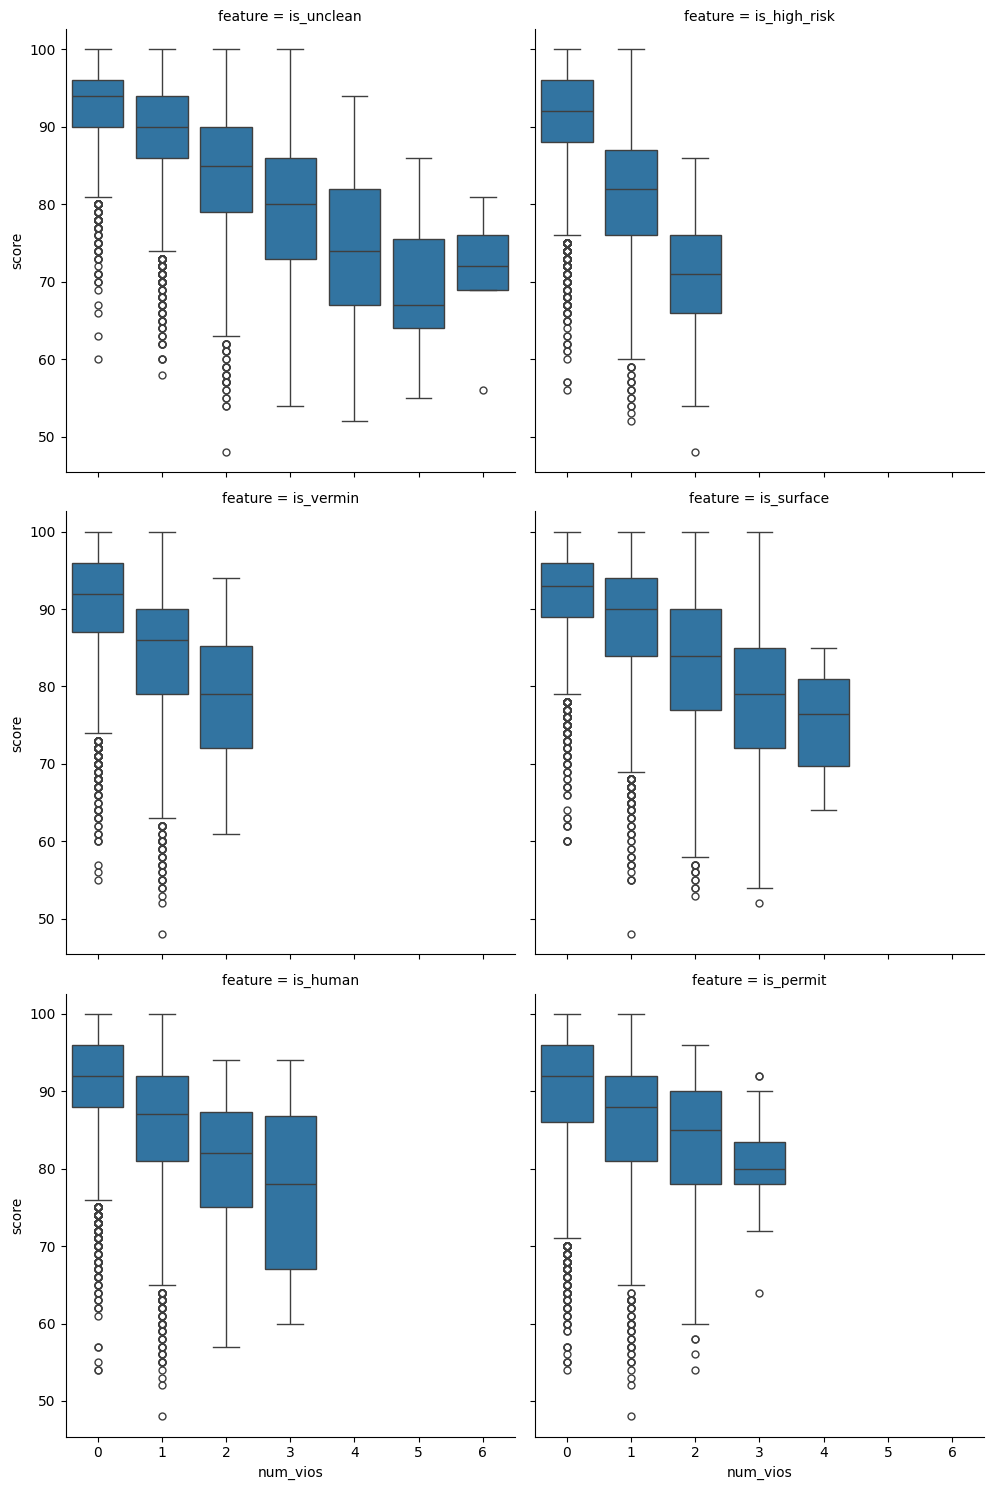

In [60]:
sns.catplot(
    x='num_vios', y='score',
    col='feature', col_wrap=2,
    kind='box',
    data=violation_type_and_scores
);

Above we can observe:
* The inspection score generally goes down with increasing numbers of violations, as expected.
* Depending on the violation keyword, inspections scores on average go down at slightly different rates.
* For example, that if a restaurant inspection involved 2 violations with the keyword "vermin", the average score for that inspection would be a little bit below 80.